#  Ministry of Finance Annual Reports — NLP Analysis (1991–2025)

### Natural Language Processing: Sentiment, Hedging, Uncertainty & Directional Tone

---

Key Events Covered:
-  1991 — Narasimha Rao Reforms (LPG: Liberalisation, Privatisation, Globalisation)
-  1998 — Pokhran Nuclear Tests
-  1996/2004/2014 — Political Party Changes
-  1991–2005 — Globalisation & Privatisation Wave
-  2016 — Demonetisation
-  2017 — GST Introduction
-  2020 — COVID-19 Pandemic
-  2008 / 2022 — Global Stress Events



##  Section 0: Install Dependencies

In [50]:

!pip install -q nltk textblob vaderSentiment matplotlib seaborn pandas numpy \
                wordcloud pdfplumber plotly kaleido scikit-learn scipy

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('vader_lexicon', quiet=True)

print("All dependencies installed and ready!")

All dependencies installed and ready!


##  Section 1: Load Data
### Option A — Upload Real PDFs | Option B — Use Simulated Data

In [51]:
import pdfplumber, os
from pathlib import Path

USE_REAL_PDFS = False

# Define folder where your MoF PDF reports are stored
PDF_FOLDER = r"C:\Users\talma\Desktop\finance analytics\mof analysis\pdfs"  # Change this to your PDF directory
real_texts = {}

if USE_REAL_PDFS:
    if os.path.exists(PDF_FOLDER):
        print(f"Scanning for PDFs in: {PDF_FOLDER}")
        for fname in os.listdir(PDF_FOLDER):
            if fname.endswith('.pdf'):
                try:
                    # Extract year from filename (e.g., "1991.pdf" or "mof_1991.pdf")
                    year = int(''.join(filter(str.isdigit, fname.split('.')[0])))
                    pdf_path = os.path.join(PDF_FOLDER, fname)
                    
                    with pdfplumber.open(pdf_path) as pdf:
                        text = ' '.join([p.extract_text() or '' for p in pdf.pages])
                    real_texts[year] = text
                    print(f"   Loaded {year}: {len(text):,} chars from {fname}")
                except Exception as e:
                    print(f"   Could not parse {fname}: {e}")
        print(f"\nLoaded {len(real_texts)} reports from PDFs.")
    else:
        print(f"PDF folder not found: {PDF_FOLDER}")
        print("Using simulated data instead. Create your PDF folder and set USE_REAL_PDFS=True to use real reports.")
else:
    print("Using simulated NLP data (Section 2). Set USE_REAL_PDFS=True and place PDF files in a folder to use real reports.")

Using simulated NLP data (Section 2). Set USE_REAL_PDFS=True and place PDF files in a folder to use real reports.


##  Section 2: Simulate Linguistically Calibrated MoF Report Data (1991–2025)

In [52]:

import numpy as np, pandas as pd

years = list(range(1991, 2026))

events = {
    1991: "Narasimha Rao Reforms\n(LPG)",
    1993: "Rupee Convertibility",
    1998: "Pokhran-II\nNuclear Tests",
    1999: "Kargil War",
    2001: "Dot-com Bust",
    2004: "UPA Govt Begins",
    2008: "Global Financial Crisis",
    2014: "NDA Govt Begins",
    2016: "Demonetisation",
    2017: "GST Introduction",
    2020: "COVID-19 Pandemic",
    2022: "Global Inflation Shock",
    2024: "Elections + Geo-stress",
}


def get_party(yr):
    if yr <= 1995: return "INC (Narasimha Rao)"
    elif yr <= 1997: return "Coalition (Deve Gowda/Gujral)"
    elif yr <= 2003: return "NDA (Vajpayee)"
    elif yr <= 2013: return "UPA (Manmohan Singh)"
    else:            return "NDA (Modi)"


gdp = {
    1991:1.1,  1992:5.4,  1993:4.8,  1994:6.7,  1995:7.6,
    1996:7.5,  1997:4.0,  1998:6.2,  1999:8.5,  2000:4.0,
    2001:4.8,  2002:3.8,  2003:7.9,  2004:7.8,  2005:9.3,
    2006:9.3,  2007:9.8,  2008:3.9,  2009:8.4,  2010:10.3,
    2011:6.6,  2012:5.5,  2013:6.4,  2014:7.4,  2015:8.0,
    2016:8.3,  2017:6.8,  2018:6.5,  2019:4.0,  2020:-6.6,
    2021:8.7,  2022:7.2,  2023:7.6,  2024:8.2,  2025:6.8
}

inflation = {
    1991:13.9, 1992:11.8, 1993:6.4,  1994:10.2, 1995:10.0,
    1996:9.0,  1997:7.2,  1998:13.2, 1999:4.7,  2000:4.0,
    2001:3.7,  2002:4.3,  2003:3.8,  2004:3.8,  2005:4.2,
    2006:6.1,  2007:6.4,  2008:8.3,  2009:10.9, 2010:12.1,
    2011:8.9,  2012:9.3,  2013:10.9, 2014:6.7,  2015:5.9,
    2016:4.5,  2017:3.3,  2018:3.9,  2019:3.7,  2020:6.2,
    2021:5.1,  2022:6.7,  2023:5.4,  2024:4.9,  2025:4.2
}

fiscal_deficit = {
    1991:5.6, 1992:5.7, 1993:7.4, 1994:5.8, 1995:5.1,
    1996:5.0, 1997:4.8, 1998:5.1, 1999:5.4, 2000:5.6,
    2001:5.7, 2002:5.9, 2003:4.5, 2004:3.9, 2005:4.1,
    2006:3.3, 2007:2.5, 2008:6.0, 2009:6.5, 2010:4.8,
    2011:5.9, 2012:5.7, 2013:4.6, 2014:4.0, 2015:3.9,
    2016:3.5, 2017:3.5, 2018:3.4, 2019:4.6, 2020:9.5,
    2021:6.7, 2022:6.4, 2023:5.9, 2024:5.6, 2025:5.1
}


np.random.seed(42)


hedging_base = [
    38, 36, 42, 35, 33,
    34, 40, 52, 48, 45,
    43, 46, 38, 35, 30,
    28, 25, 62, 55, 42,
    44, 46, 40, 35, 30,
    55, 50, 42, 48, 75,
    60, 52, 45, 42, 40
]
hedging = [h + np.random.normal(0, 1.5) for h in hedging_base]


pos_base = [
    0.38, 0.44, 0.46, 0.52, 0.55,
    0.50, 0.47, 0.35, 0.40, 0.45,
    0.48, 0.44, 0.52, 0.56, 0.62,
    0.64, 0.66, 0.38, 0.48, 0.58,
    0.55, 0.52, 0.50, 0.56, 0.60,
    0.45, 0.48, 0.55, 0.50, 0.30,
    0.50, 0.58, 0.60, 0.62, 0.64
]
positive_ratio = [p + np.random.normal(0, 0.015) for p in pos_base]
negative_ratio = [1 - p - abs(np.random.normal(0, 0.01)) for p in positive_ratio]
neutral_ratio  = [max(0, 1 - pos_ratio - neg_ratio)
                  for pos_ratio, neg_ratio in zip(positive_ratio, negative_ratio)]


uncert_base = [
    62, 58, 65, 54, 50,
    52, 60, 78, 72, 68,
    65, 70, 55, 50, 44,
    40, 36, 80, 74, 60,
    62, 65, 58, 52, 46,
    72, 68, 55, 62, 88,
    76, 65, 55, 50, 48
]
uncertainty_index = [u + np.random.normal(0, 2) for u in uncert_base]


dir_base = [
    -0.20, 0.05, 0.10, 0.20, 0.30,
     0.15, 0.00,-0.35,-0.20,-0.10,
     0.05,-0.05, 0.25, 0.30, 0.40,
     0.42, 0.44,-0.40,-0.25, 0.10,
     0.15, 0.10, 0.12, 0.28, 0.38,
    -0.15,-0.05, 0.25, 0.15,-0.55,
     0.20, 0.32, 0.38, 0.40, 0.42
]
directional_sentiment = [d + np.random.normal(0, 0.02) for d in dir_base]


pos_words = [round(280 * p + np.random.normal(0,5)) for p in positive_ratio]
neg_words  = [round(280 * n + np.random.normal(0,5)) for n in negative_ratio]


vader_compound = [0.6*d + 0.2*(p-0.5) + np.random.normal(0,0.03)
                  for d, p in zip(dir_base, pos_base)]


passive_base = [55-i*0.4 + (5 if y in [1991,1998,2008,2016,2020] else 0)
                + np.random.normal(0,1.5)
                for i,(y) in enumerate(years)]
passive_pct = [max(30, min(70, p)) for p in passive_base]


sent_len = [28 + 0.1*i + (3 if y in [2016,2017,2020] else 0)
            + np.random.normal(0,1)
            for i,y in enumerate(years)]


jargon_base = [22 + 0.5*i + (8 if y in [2017,2020,2022] else 0)
               + np.random.normal(0,1.5)
               for i,y in enumerate(years)]


df = pd.DataFrame({
    'year':                years,
    'party':               [get_party(y) for y in years],
    'event':               [events.get(y, '') for y in years],
    'gdp_growth':          [gdp[y] for y in years],
    'inflation':           [inflation[y] for y in years],
    'fiscal_deficit':      [fiscal_deficit[y] for y in years],
    'hedging_per_1k':      hedging,
    'positive_ratio':      positive_ratio,
    'negative_ratio':      negative_ratio,
    'neutral_ratio':       neutral_ratio,
    'uncertainty_index':   uncertainty_index,
    'directional_sent':    directional_sentiment,
    'pos_words_per_1k':    pos_words,
    'neg_words_per_1k':    neg_words,
    'vader_compound':      vader_compound,
    'passive_voice_pct':   passive_pct,
    'avg_sent_len':        sent_len,
    'jargon_density':      jargon_base,
})

print(" Dataset created:", df.shape)
df.head(5)

 Dataset created: (35, 18)


,year,party,event,gdp_growth,inflation,fiscal_deficit,hedging_per_1k,positive_ratio,negative_ratio,neutral_ratio,uncertainty_index,directional_sent,pos_words_per_1k,neg_words_per_1k,vader_compound,passive_voice_pct,avg_sent_len,jargon_density
0,1991,INC (Narasimha Rao),Narasimha Rao Reforms\n(LPG),1.1,13.9,5.6,38.745071,0.361687,0.634699,0.003614,62.808102,-0.195451,105,181,-0.154035,60.170276,28.021004,22.466361
1,1992,INC (Narasimha Rao),,5.4,11.8,5.7,35.792604,0.443133,0.541487,0.015380,61.772372,0.076143,124,157,0.003752,55.593196,28.781953,24.713034
2,1993,INC (Narasimha Rao),Rupee Convertibility,4.8,6.4,7.4,42.971533,0.430605,0.569037,0.000358,65.349156,0.067850,128,164,0.032400,56.579025,27.889733,24.286489
3,1994,INC (Narasimha Rao),,6.7,10.2,5.8,37.284545,0.500077,0.484276,0.015646,54.515101,0.203693,139,139,0.176964,51.943277,28.624166,23.260092
4,1995,INC (Narasimha Rao),,7.6,10.0,5.1,32.648770,0.552953,0.420850,0.026197,49.851108,0.305198,168,116,0.202149,56.599550,28.269857,23.971476


##  Section 3: Setup — Plotting Theme & Helpers

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.facecolor':  '#0F1117',
    'axes.facecolor':    '#1A1D2E',
    'axes.edgecolor':    '#3A3D5C',
    'axes.labelcolor':   '#E0E0E0',
    'xtick.color':       '#A0A0C0',
    'ytick.color':       '#A0A0C0',
    'text.color':        '#E0E0E0',
    'grid.color':        '#2A2D4A',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})


PARTY_COLORS = {
    'INC (Narasimha Rao)':         '#19A7CE',
    'Coalition (Deve Gowda/Gujral)':'#F7C59F',
    'NDA (Vajpayee)':              '#FF6B35',
    'UPA (Manmohan Singh)':        '#6BCB77',
    'NDA (Modi)':                  '#FF9F1C',
}

EVENT_YEARS = list(events.keys())
EVENT_LABELS = list(events.values())

def add_event_lines(ax, df, color='#FF4560', alpha=0.4, fontsize=7):
    """Add vertical event lines to any axis."""
    ylim = ax.get_ylim()
    for yr, lbl in events.items():
        ax.axvline(yr, color=color, alpha=alpha, linewidth=1, linestyle=':')
        ax.text(yr+0.1, ylim[1]*0.97, lbl,
                rotation=90, fontsize=5.5, color='#FF8FA3', alpha=0.85,
                va='top', ha='left')

def add_party_bands(ax, df):
    """Shade background by ruling party."""
    party_spans = [
        (1991, 1995, 'INC (Narasimha Rao)'),
        (1996, 1997, 'Coalition (Deve Gowda/Gujral)'),
        (1998, 2003, 'NDA (Vajpayee)'),
        (2004, 2013, 'UPA (Manmohan Singh)'),
        (2014, 2025, 'NDA (Modi)'),
    ]
    for start, end, party in party_spans:
        ax.axvspan(start-0.5, end+0.5, alpha=0.07,
                   color=PARTY_COLORS[party], zorder=0)

def party_legend():
    return [mpatches.Patch(facecolor=c, alpha=0.4, label=p)
            for p,c in PARTY_COLORS.items()]

print("Plotting theme & helpers ready.")

Plotting theme & helpers ready.


##  Chart 1: GDP Growth & Inflation (1991–2025) with Event Markers

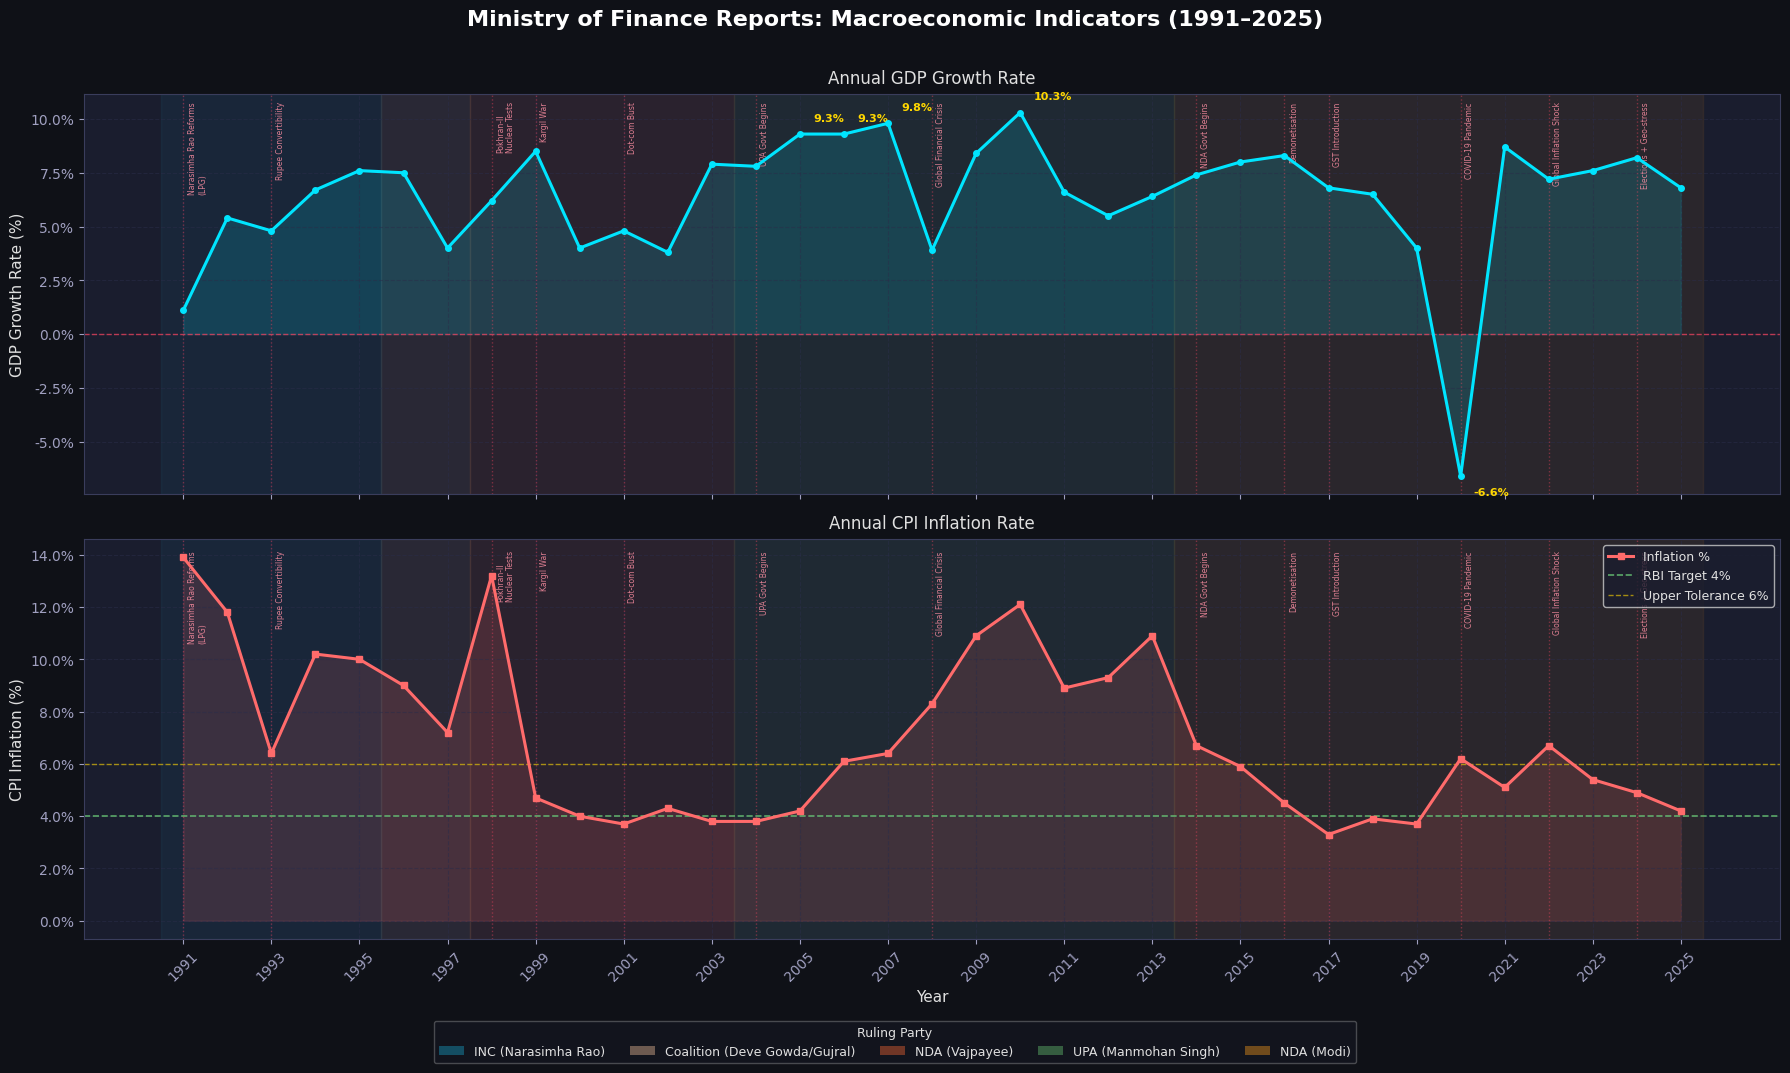

 Chart 1 saved.


In [54]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle('Ministry of Finance Reports: Macroeconomic Indicators (1991–2025)',
             fontsize=16, fontweight='bold', color='white', y=1.01)


ax1 = axes[0]
add_party_bands(ax1, df)
ax1.plot(df.year, df.gdp_growth, color='#00E5FF', linewidth=2.2,
         marker='o', markersize=4, zorder=5, label='GDP Growth %')
ax1.fill_between(df.year, df.gdp_growth, alpha=0.15, color='#00E5FF')
ax1.axhline(0, color='#FF4560', linewidth=1, linestyle='--', alpha=0.7)
ax1.set_ylabel('GDP Growth Rate (%)', fontsize=11)
ax1.set_title('Annual GDP Growth Rate', fontsize=12, pad=8)
ax1.grid(True, axis='both')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1f}%'))
add_event_lines(ax1, df)


for _, row in df[(df.gdp_growth < 0) | (df.gdp_growth > 9)].iterrows():
    ax1.annotate(f"{row.gdp_growth:.1f}%",
                 xy=(row.year, row.gdp_growth),
                 xytext=(row.year+0.3, row.gdp_growth + (0.6 if row.gdp_growth > 0 else -0.9)),
                 fontsize=8, color='#FFD700', fontweight='bold')


ax2 = axes[1]
add_party_bands(ax2, df)
ax2.plot(df.year, df.inflation, color='#FF6B6B', linewidth=2.2,
         marker='s', markersize=4, zorder=5, label='Inflation %')
ax2.fill_between(df.year, df.inflation, alpha=0.15, color='#FF6B6B')
ax2.axhline(4, color='#6BCB77', linewidth=1.2, linestyle='--',
            alpha=0.8, label='RBI Target 4%')
ax2.axhline(6, color='#FFD700', linewidth=1, linestyle='--',
            alpha=0.6, label='Upper Tolerance 6%')
ax2.set_ylabel('CPI Inflation (%)', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_title('Annual CPI Inflation Rate', fontsize=12, pad=8)
ax2.grid(True, axis='both')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax2.set_xticks(range(1991, 2026, 2))
ax2.tick_params(axis='x', rotation=45)
add_event_lines(ax2, df)
ax2.legend(loc='upper right', fontsize=9)


fig.legend(handles=party_legend(), loc='lower center', ncol=5,
           fontsize=9, framealpha=0.3, title='Ruling Party',
           title_fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('chart1_gdp_inflation.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 1 saved.")

## Chart 2: Hedging Words & Uncertainty Index — Language of Doubt

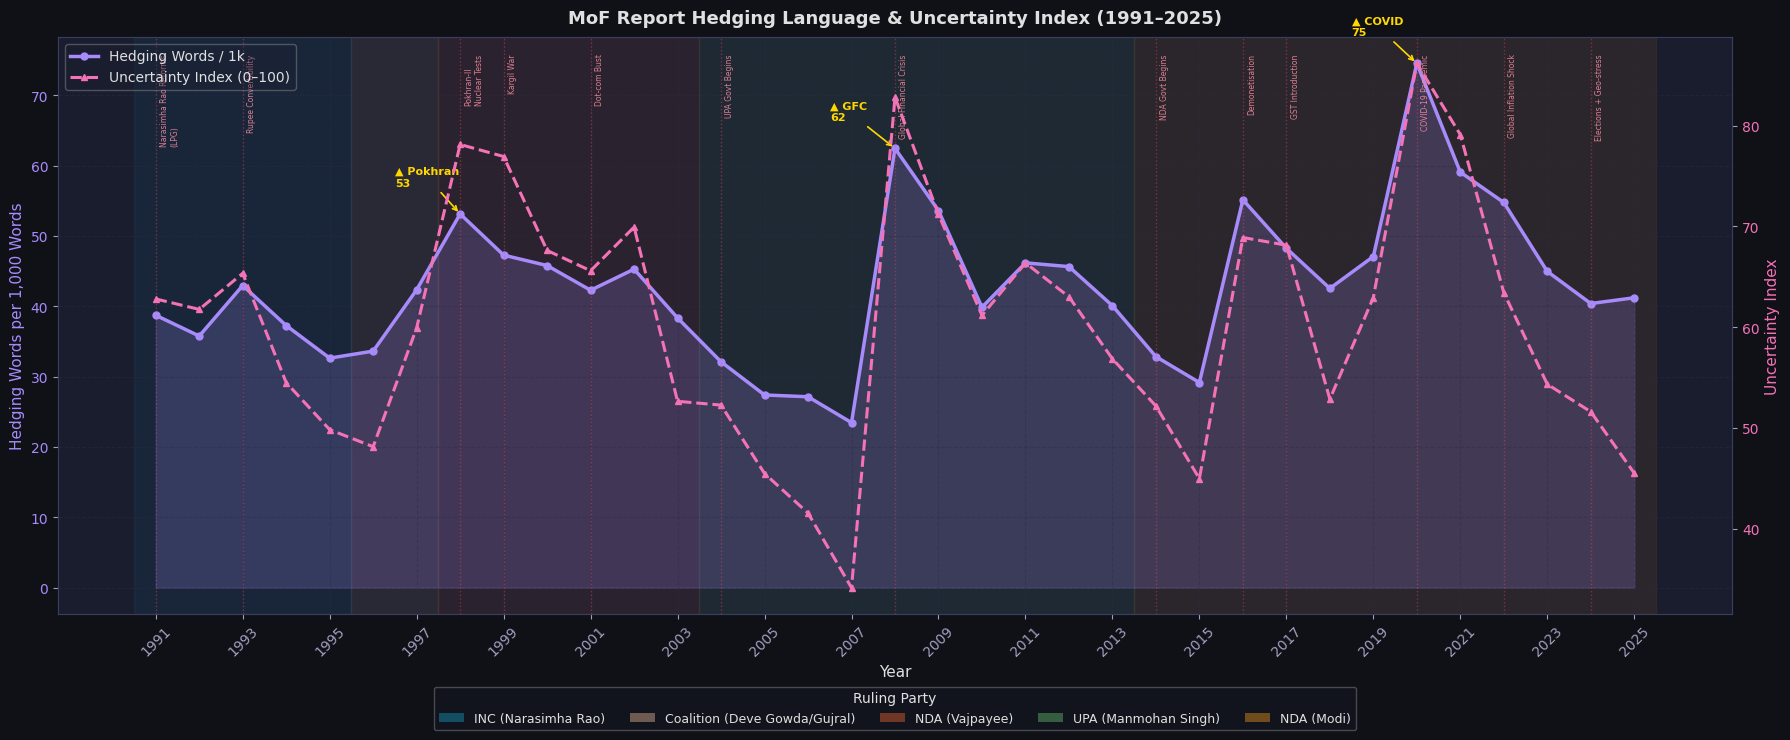

 Chart 2 saved.


In [55]:
fig, ax1 = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('#0F1117')

add_party_bands(ax1, df)


color_h = '#A78BFA'
ax1.plot(df.year, df.hedging_per_1k, color=color_h, linewidth=2.5,
         marker='o', markersize=5, label='Hedging Words / 1k')
ax1.fill_between(df.year, df.hedging_per_1k, alpha=0.2, color=color_h)
ax1.set_ylabel('Hedging Words per 1,000 Words', color=color_h, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_h)


ax2 = ax1.twinx()
color_u = '#F472B6'
ax2.plot(df.year, df.uncertainty_index, color=color_u, linewidth=2.2,
         marker='^', markersize=5, linestyle='--',
         label='Uncertainty Index (0–100)')
ax2.set_ylabel('Uncertainty Index', color=color_u, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_u)

ax1.set_xlabel('Year', fontsize=11)
ax1.set_title('MoF Report Hedging Language & Uncertainty Index (1991–2025)',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_xticks(range(1991, 2026, 2))
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.4)

add_event_lines(ax1, df, fontsize=6)


for yr, label in [(1998,'Pokhran'), (2008,'GFC'), (2020,'COVID')]:
    row = df[df.year==yr].iloc[0]
    ax1.annotate(f"▲ {label}\n{row.hedging_per_1k:.0f}",
                 xy=(yr, row.hedging_per_1k),
                 xytext=(yr-1.5, row.hedging_per_1k+4),
                 fontsize=8, color='#FFD700', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1.2))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=10,
           framealpha=0.3)

fig.legend(handles=party_legend(), loc='lower center', ncol=5,
           fontsize=9, framealpha=0.3, title='Ruling Party',
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig('chart2_hedging_uncertainty.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 2 saved.")

##  Chart 3: Positive vs Negative Word Count (Stacked Area)

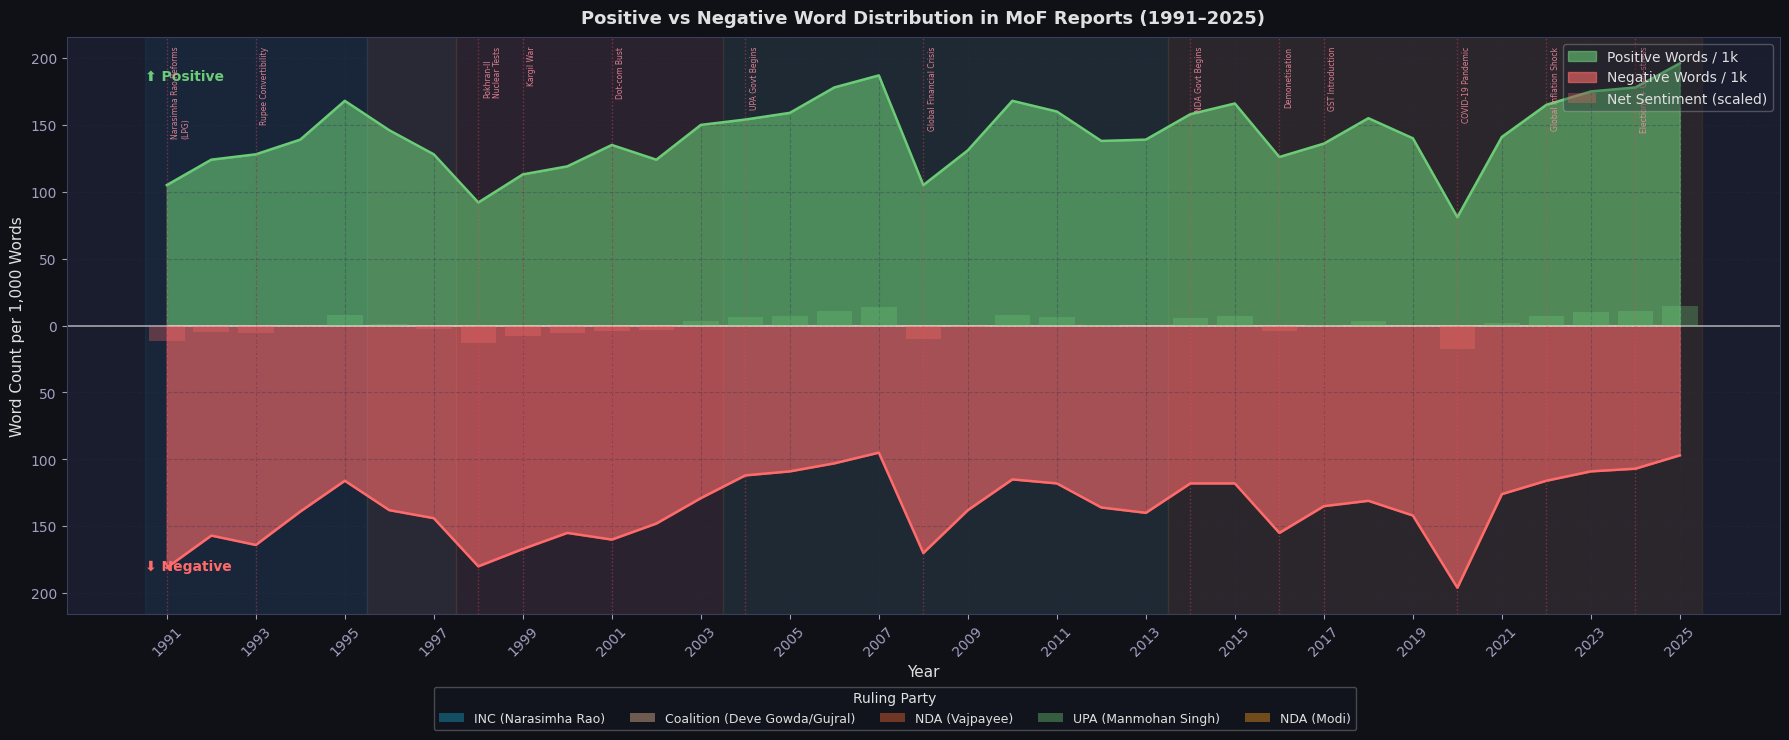

Chart 3 saved.


In [56]:
fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('#0F1117')

add_party_bands(ax, df)

ax.fill_between(df.year, df.pos_words_per_1k, alpha=0.6,
                color='#6BCB77', label='Positive Words / 1k')
ax.fill_between(df.year, -df.neg_words_per_1k, alpha=0.6,
                color='#FF6B6B', label='Negative Words / 1k')
ax.plot(df.year, df.pos_words_per_1k, color='#6BCB77', linewidth=1.8)
ax.plot(df.year, -df.neg_words_per_1k, color='#FF6B6B', linewidth=1.8)
ax.axhline(0, color='white', linewidth=1.2, alpha=0.6)


net = df.pos_words_per_1k - df.neg_words_per_1k
ax.bar(df.year, net*0.15, bottom=0, color=[
    '#6BCB77' if n > 0 else '#FF6B6B' for n in net],
    alpha=0.3, zorder=2, label='Net Sentiment (scaled)')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Word Count per 1,000 Words', fontsize=11)
ax.set_title('Positive vs Negative Word Distribution in MoF Reports (1991–2025)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(range(1991, 2026, 2))
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)


yticks = ax.get_yticks()
ax.set_yticklabels([f'{abs(int(t))}' for t in yticks])
ax.text(1990.5, ax.get_ylim()[1]*0.85, '⬆ Positive',
        color='#6BCB77', fontsize=10, fontweight='bold')
ax.text(1990.5, ax.get_ylim()[0]*0.85, '⬇ Negative',
        color='#FF6B6B', fontsize=10, fontweight='bold')

add_event_lines(ax, df, fontsize=6)
ax.legend(loc='upper right', fontsize=10, framealpha=0.3)

fig.legend(handles=party_legend(), loc='lower center', ncol=5,
           fontsize=9, framealpha=0.3, title='Ruling Party',
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig('chart3_pos_neg_words.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print("Chart 3 saved.")

##  Chart 4: Directional Sentiment Ratio (Forward-Looking Optimism)

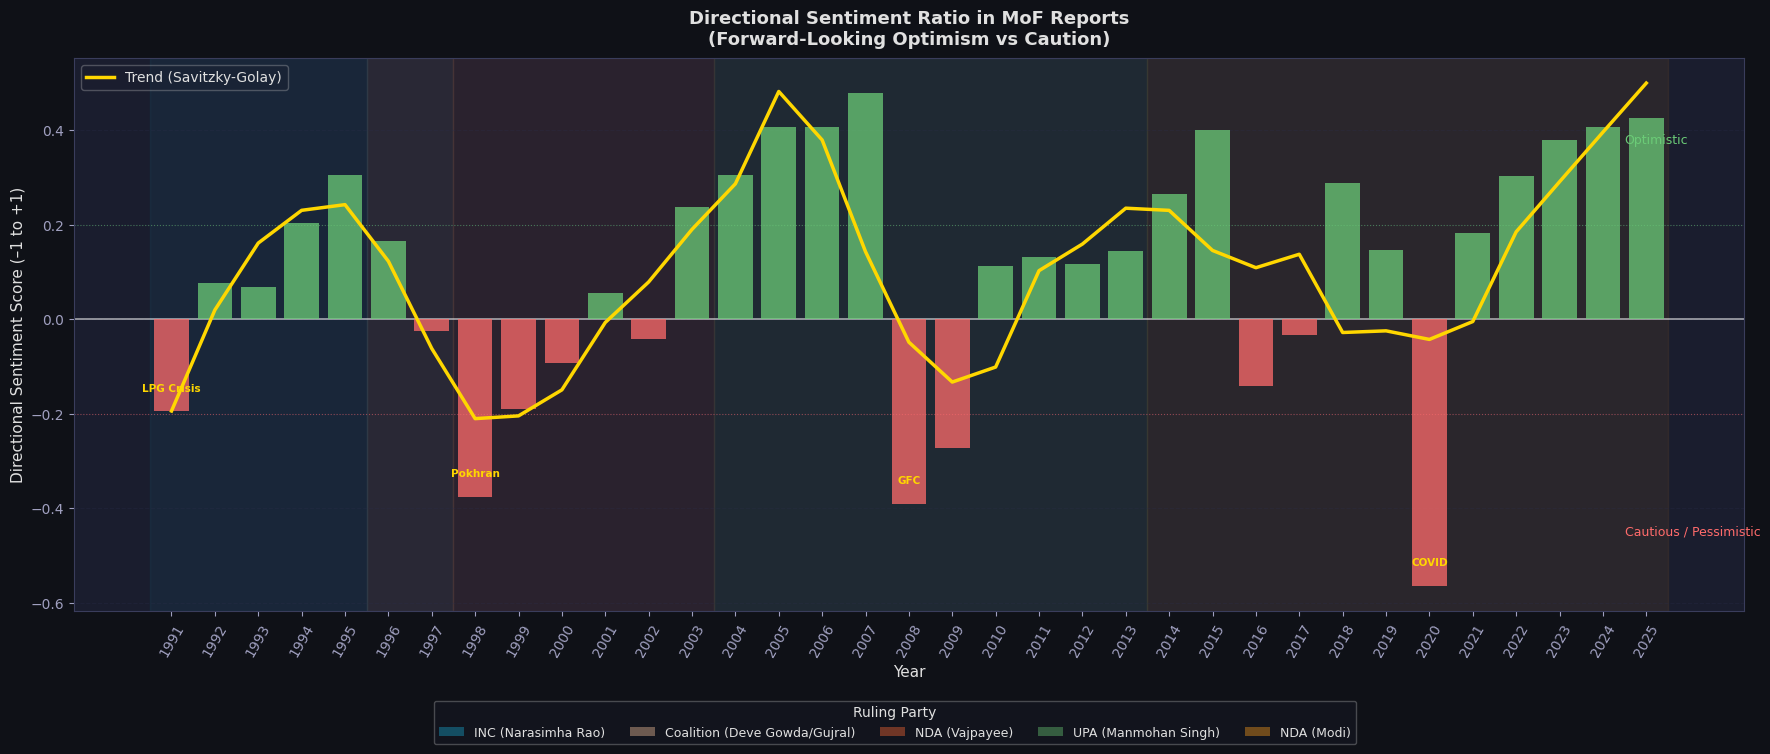

 Chart 4 saved.


In [57]:
fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('#0F1117')

add_party_bands(ax, df)

colors = ['#6BCB77' if v >= 0 else '#FF6B6B' for v in df.directional_sent]
ax.bar(df.year, df.directional_sent, color=colors, alpha=0.75, zorder=3)


from scipy.signal import savgol_filter
smooth = savgol_filter(df.directional_sent, window_length=7, polyorder=2)
ax.plot(df.year, smooth, color='#FFD700', linewidth=2.5, zorder=5,
        label='Trend (Savitzky-Golay)')

ax.axhline(0, color='white', linewidth=1.2, linestyle='-', alpha=0.6)
ax.axhline(0.2, color='#6BCB77', linewidth=0.8, linestyle=':', alpha=0.5)
ax.axhline(-0.2, color='#FF6B6B', linewidth=0.8, linestyle=':', alpha=0.5)


ax.text(2024.5, 0.38, 'Optimistic', color='#6BCB77', fontsize=9, va='center')
ax.text(2024.5, -0.45, 'Cautious / Pessimistic', color='#FF6B6B', fontsize=9, va='center')


for yr, lbl in [(1991,'LPG Crisis'), (2008,'GFC'), (2020,'COVID'), (1998,'Pokhran')]:
    row = df[df.year==yr].iloc[0]
    offset = 0.06 if row.directional_sent < 0 else -0.06
    va = 'top' if row.directional_sent < 0 else 'bottom'
    ax.text(yr, row.directional_sent + offset, lbl,
            fontsize=7.5, color='#FFD700', ha='center', va=va, fontweight='bold')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Directional Sentiment Score (–1 to +1)', fontsize=11)
ax.set_title('Directional Sentiment Ratio in MoF Reports\n(Forward-Looking Optimism vs Caution)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(range(1991, 2026, 1))
ax.tick_params(axis='x', rotation=60)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(fontsize=10, framealpha=0.3)

fig.legend(handles=party_legend(), loc='lower center', ncol=5,
           fontsize=9, framealpha=0.3, title='Ruling Party',
           bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig('chart4_directional_sentiment.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 4 saved.")

##  Chart 5: Sentiment Ratio — Stacked 100% Area (Positive / Neutral / Negative)

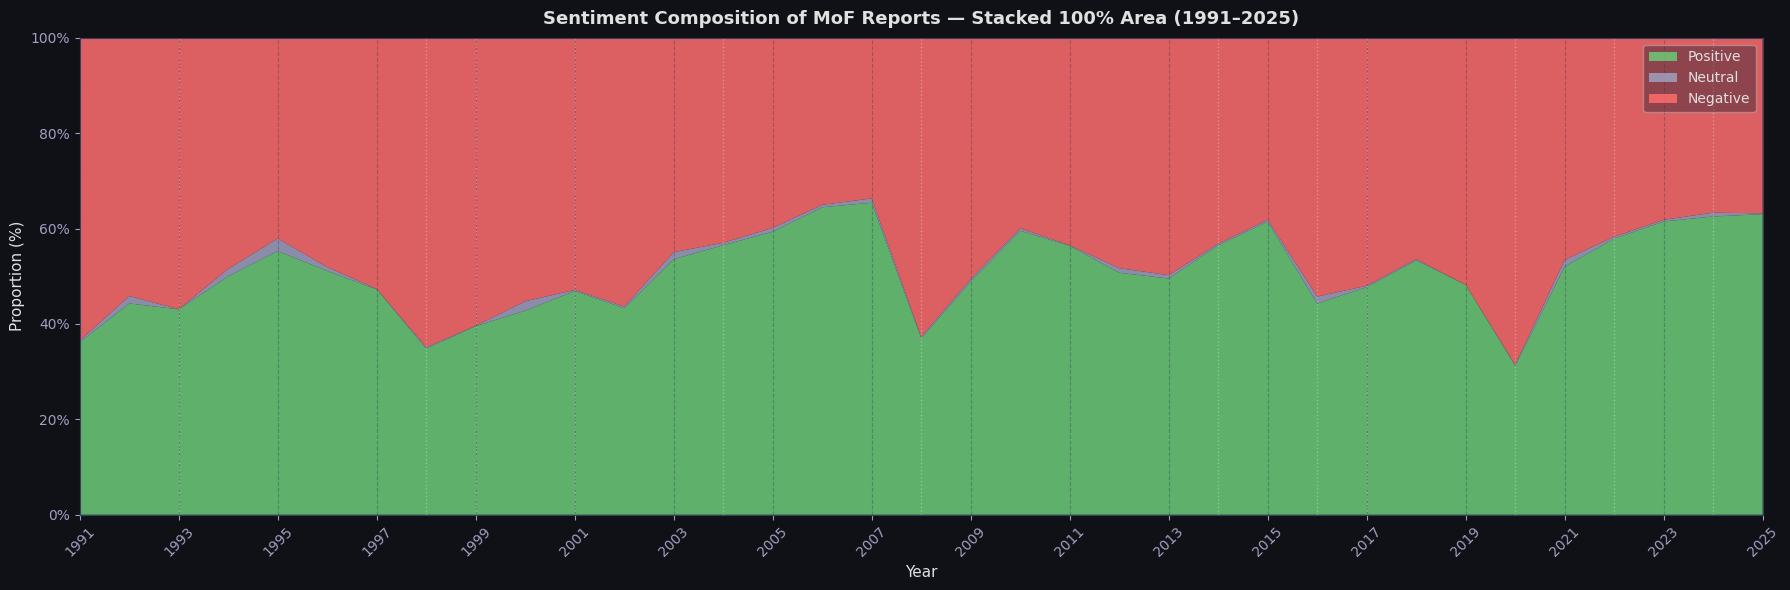

 Chart 5 saved.


In [58]:
fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor('#0F1117')


total = df.positive_ratio + df.negative_ratio + df.neutral_ratio
p = df.positive_ratio / total * 100
n = df.negative_ratio / total * 100
neu = df.neutral_ratio  / total * 100

ax.stackplot(df.year,
             p, neu, n,
             labels=['Positive', 'Neutral', 'Negative'],
             colors=['#6BCB77','#A0A0C0','#FF6B6B'],
             alpha=0.85)

ax.set_xlim(1991, 2025)
ax.set_ylim(0, 100)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Proportion (%)', fontsize=11)
ax.set_title('Sentiment Composition of MoF Reports — Stacked 100% Area (1991–2025)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(range(1991, 2026, 2))
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.grid(True, axis='x', alpha=0.3)

for yr, lbl in events.items():
    ax.axvline(yr, color='white', alpha=0.3, linewidth=1, linestyle=':')

ax.legend(loc='upper right', fontsize=10, framealpha=0.4)

plt.tight_layout()
plt.savefig('chart5_sentiment_stacked.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 5 saved.")

##  Chart 6: Multi-Line NLP Dashboard — All Metrics on One View

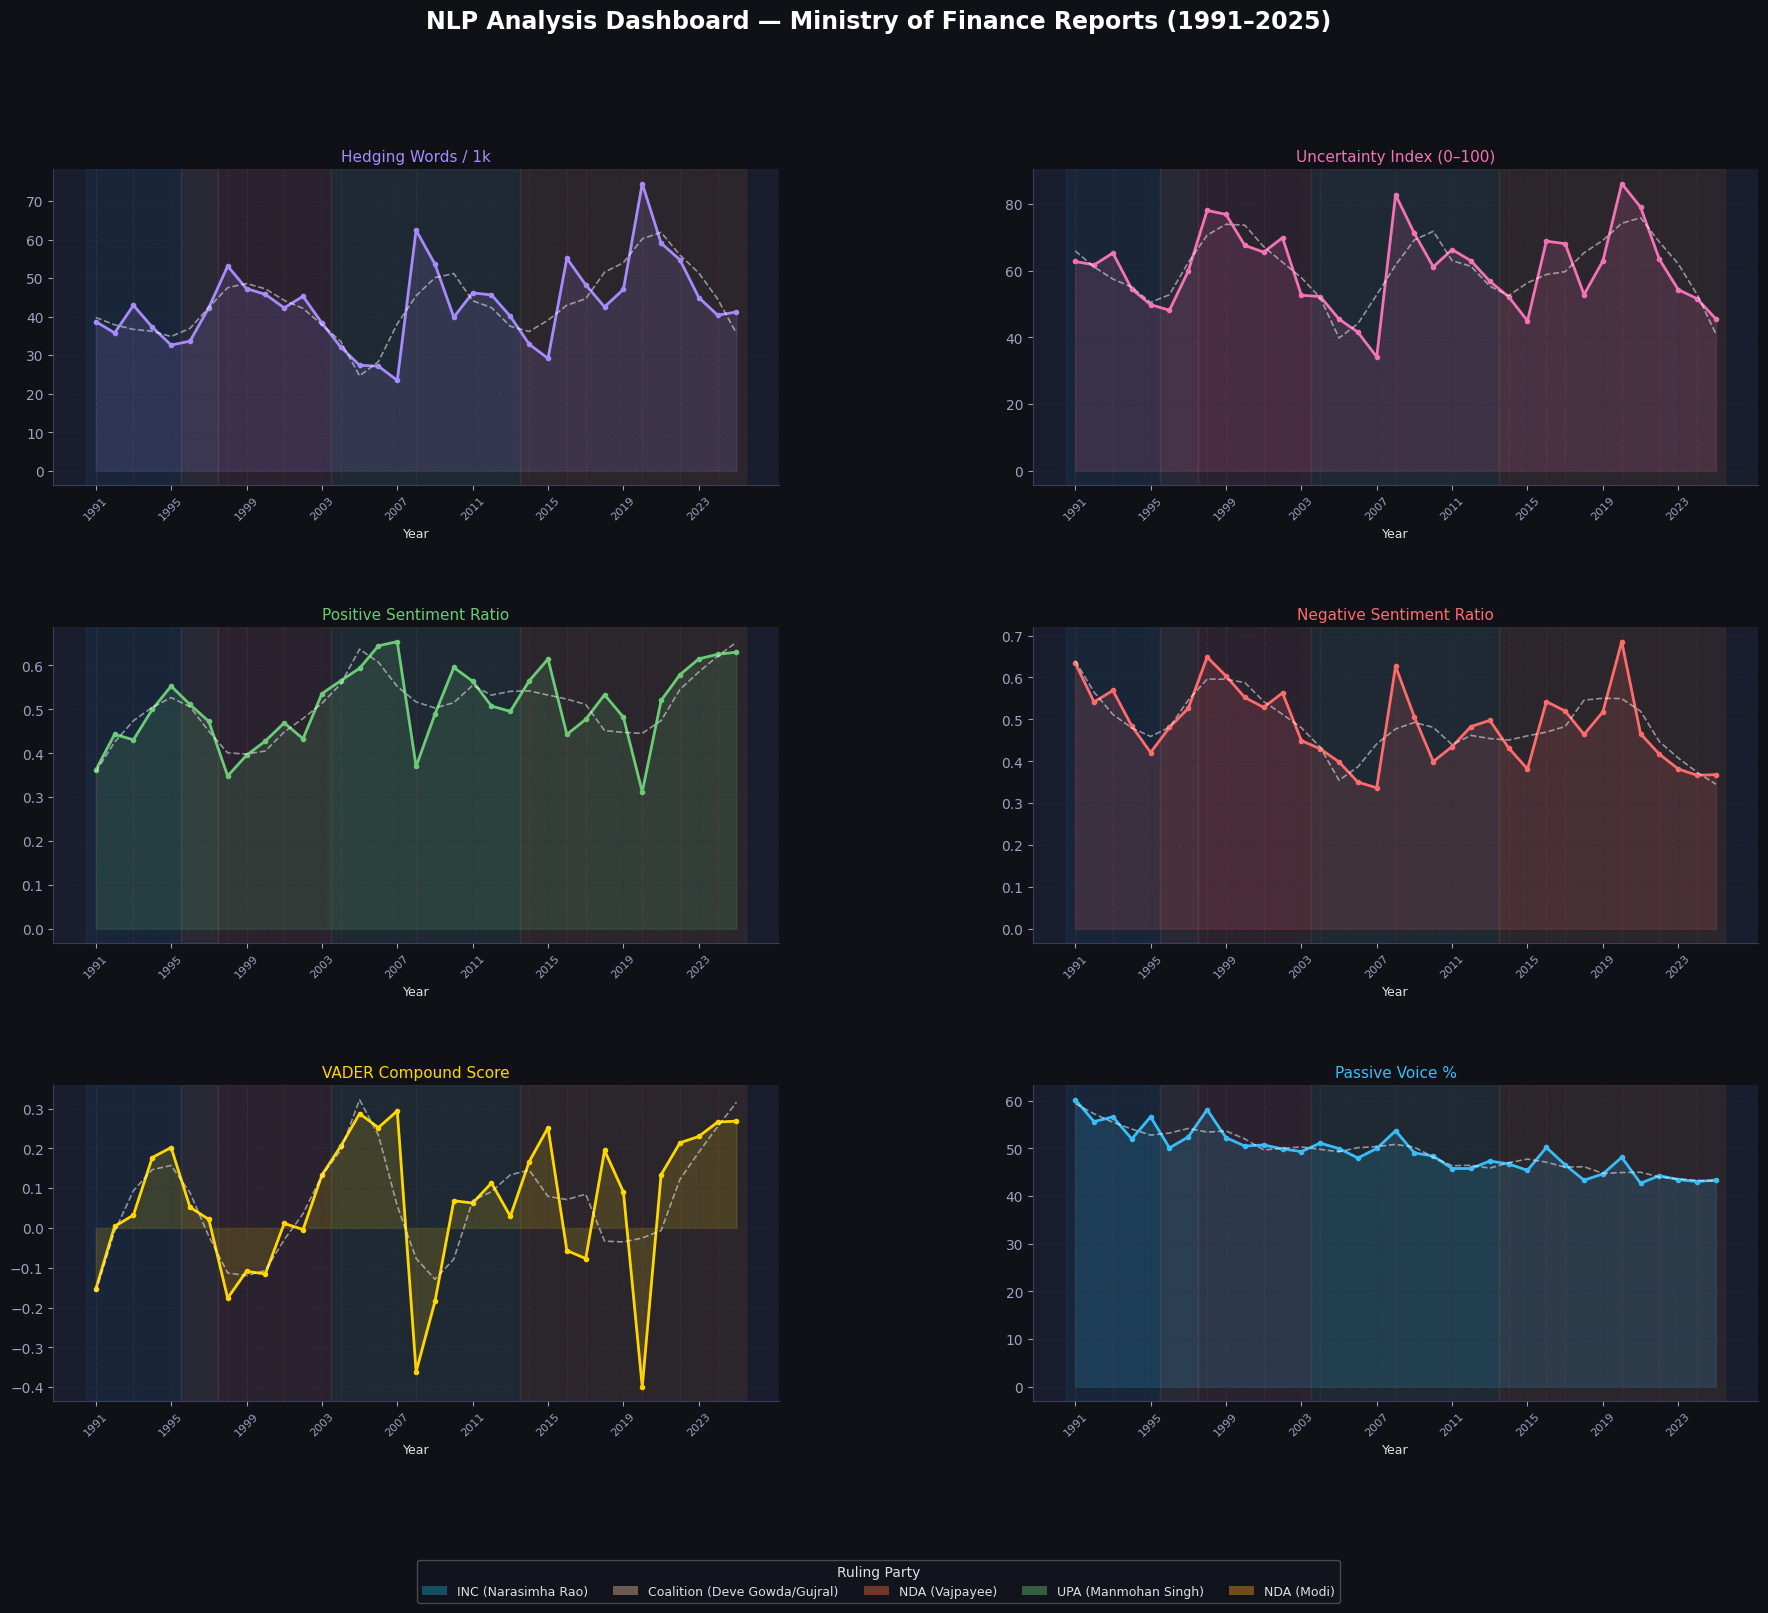

 Chart 6 saved.


In [59]:
fig = plt.figure(figsize=(22, 16), facecolor='#0F1117')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('NLP Analysis Dashboard — Ministry of Finance Reports (1991–2025)',
             fontsize=17, fontweight='bold', color='white', y=0.98)

metrics = [
    ('hedging_per_1k',    'Hedging Words / 1k',        '#A78BFA', gs[0,0]),
    ('uncertainty_index', 'Uncertainty Index (0–100)', '#F472B6', gs[0,1]),
    ('positive_ratio',    'Positive Sentiment Ratio',  '#6BCB77', gs[1,0]),
    ('negative_ratio',    'Negative Sentiment Ratio',  '#FF6B6B', gs[1,1]),
    ('vader_compound',    'VADER Compound Score',      '#FFD700', gs[2,0]),
    ('passive_voice_pct', 'Passive Voice %',           '#38BDF8', gs[2,1]),
]

for col, label, color, pos in metrics:
    ax = fig.add_subplot(pos)
    ax.set_facecolor('#1A1D2E')
    add_party_bands(ax, df)
    ax.plot(df.year, df[col], color=color, linewidth=2, marker='o', markersize=3)
    ax.fill_between(df.year, df[col], alpha=0.15, color=color)


    smooth = savgol_filter(df[col], window_length=7, polyorder=2)
    ax.plot(df.year, smooth, color='white', linewidth=1.2,
            linestyle='--', alpha=0.5, label='Trend')

    for yr in EVENT_YEARS:
        ax.axvline(yr, color='#FF4560', alpha=0.25, linewidth=0.8, linestyle=':')

    ax.set_title(label, fontsize=11, color=color, pad=6)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_xticks(range(1991,2026,4))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

fig.legend(handles=party_legend(), loc='lower center', ncol=5,
           fontsize=9, framealpha=0.3, title='Ruling Party',
           bbox_to_anchor=(0.5, -0.02))

plt.savefig('chart6_nlp_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 6 saved.")

##  Chart 7: Radar Chart — NLP Profile by Political Era

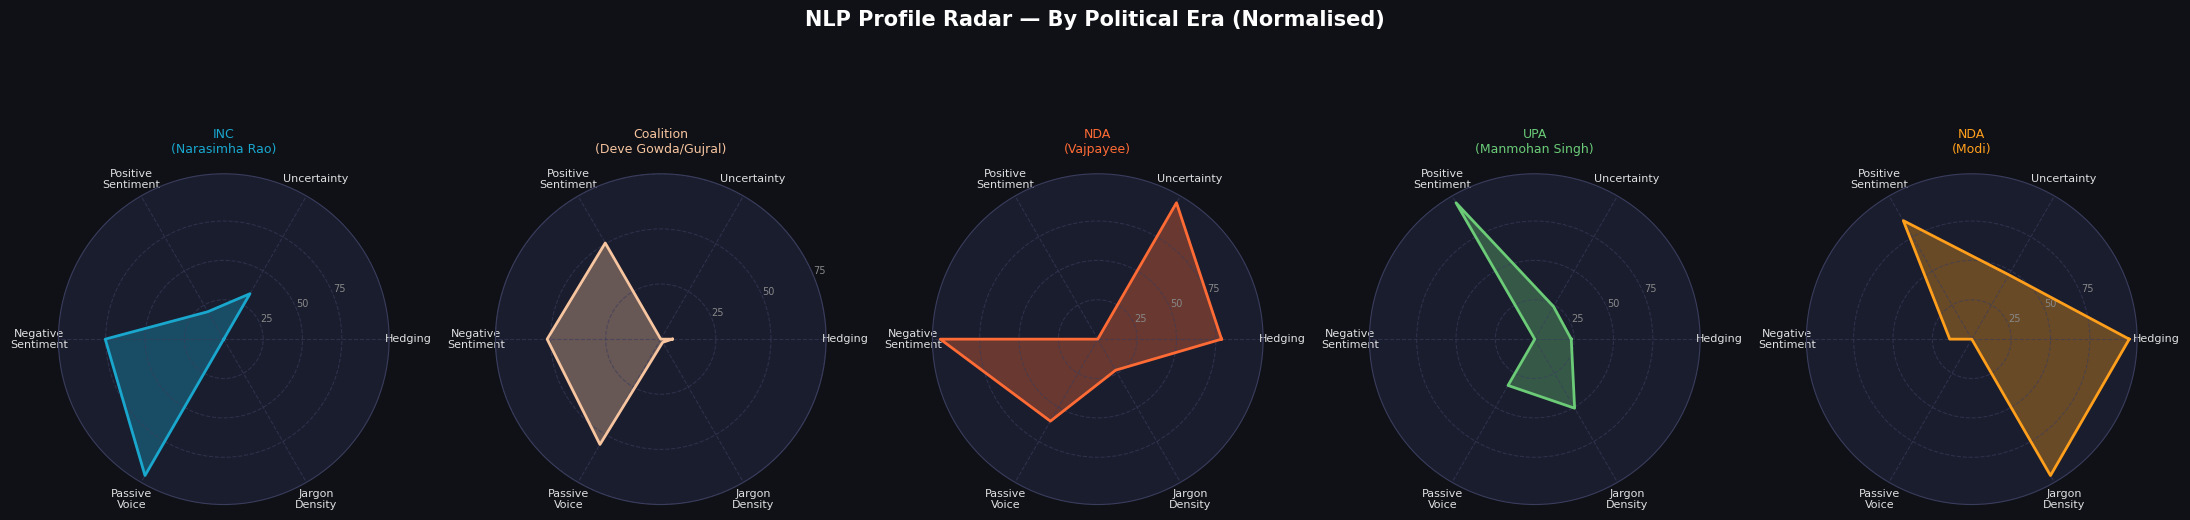

 Chart 7 saved.


In [60]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import numpy as np


nlp_cols  = ['hedging_per_1k','uncertainty_index','positive_ratio',
              'negative_ratio','passive_voice_pct','jargon_density']
era_names = ['INC (Narasimha Rao)', 'Coalition (Deve Gowda/Gujral)',
             'NDA (Vajpayee)', 'UPA (Manmohan Singh)', 'NDA (Modi)']

era_df = df.groupby('party')[nlp_cols].mean()

norm = (era_df - era_df.min()) / (era_df.max() - era_df.min())

labels  = ['Hedging', 'Uncertainty', 'Positive\nSentiment',
           'Negative\nSentiment', 'Passive\nVoice', 'Jargon\nDensity']
N       = len(labels)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 5, figsize=(22, 6),
                          subplot_kw={'polar': True},
                          facecolor='#0F1117')
fig.suptitle('NLP Profile Radar — By Political Era (Normalised)',
             fontsize=15, fontweight='bold', color='white', y=1.02)

for idx, (era, ax) in enumerate(zip(era_names, axes)):
    if era not in norm.index: continue
    vals = norm.loc[era].values.tolist()
    vals += vals[:1]
    color = list(PARTY_COLORS.values())[idx]

    ax.set_facecolor('#1A1D2E')
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, alpha=0.35, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8, color='#E0E0E0')
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['25', '50', '75'], fontsize=7, color='#888')
    ax.spines['polar'].set_color('#3A3D5C')
    ax.grid(color='#3A3D5C', alpha=0.6)

    short = era.replace(' (Narasimha Rao)','').replace(' (Deve Gowda/Gujral)','')\
               .replace(' (Vajpayee)','').replace(' (Manmohan Singh)','')\
               .replace(' (Modi)','')
    ax.set_title(era.split('(')[0].strip() + '\n(' +
                 era.split('(')[1].replace(')','') + ')',
                 fontsize=9, color=color, pad=15)

plt.tight_layout()
plt.savefig('chart7_radar_era.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 7 saved.")

##  Chart 8: Heatmap — NLP Metrics Across All Years

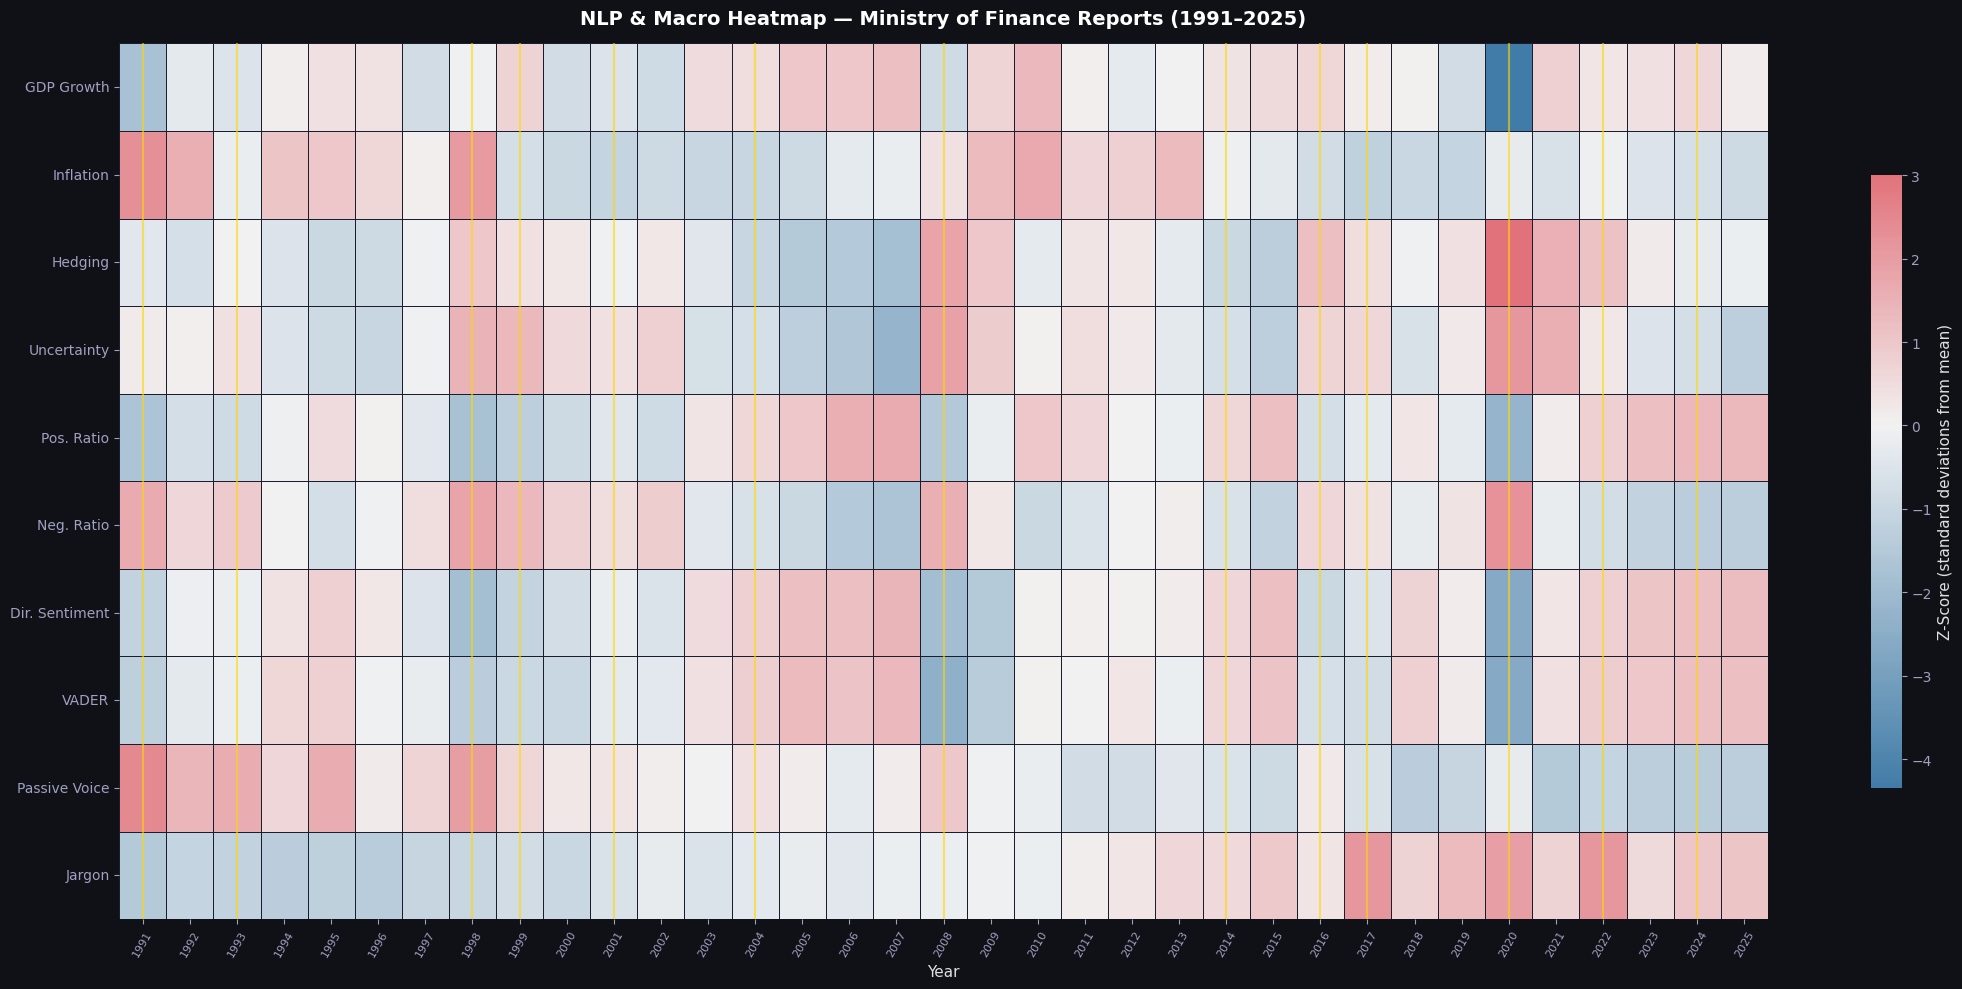

 Chart 8 saved.


In [61]:
import seaborn as sns

heat_cols = ['gdp_growth','inflation','hedging_per_1k','uncertainty_index',
             'positive_ratio','negative_ratio','directional_sent',
             'vader_compound','passive_voice_pct','jargon_density']

heat_labels = ['GDP Growth','Inflation','Hedging','Uncertainty',
               'Pos. Ratio','Neg. Ratio','Dir. Sentiment',
               'VADER','Passive Voice','Jargon']

heat_df = df.set_index('year')[heat_cols].copy()
heat_df.columns = heat_labels


from scipy import stats as scipy_stats
heat_norm = heat_df.apply(scipy_stats.zscore)

fig, ax = plt.subplots(figsize=(22, 10), facecolor='#0F1117')
ax.set_facecolor('#0F1117')

cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(heat_norm.T, ax=ax, cmap=cmap, center=0,
            linewidths=0.4, linecolor='#1A1D2E',
            cbar_kws={'label': 'Z-Score (standard deviations from mean)', 'shrink': 0.7},
            annot=False, xticklabels=True, yticklabels=True)

ax.set_title('NLP & Macro Heatmap — Ministry of Finance Reports (1991–2025)',
             fontsize=14, fontweight='bold', pad=14, color='white')
ax.set_xlabel('Year', fontsize=11)
ax.set_xticklabels(years, rotation=60, fontsize=8)
ax.set_yticklabels(heat_labels, rotation=0, fontsize=10)


for yr in EVENT_YEARS:
    if yr in years:
        xi = years.index(yr)
        ax.axvline(xi + 0.5, color='#FFD700', linewidth=1.5, alpha=0.6)

plt.tight_layout()
plt.savefig('chart8_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 8 saved.")

##  Chart 10: Scatter — GDP Growth vs Sentiment Score (by Party)

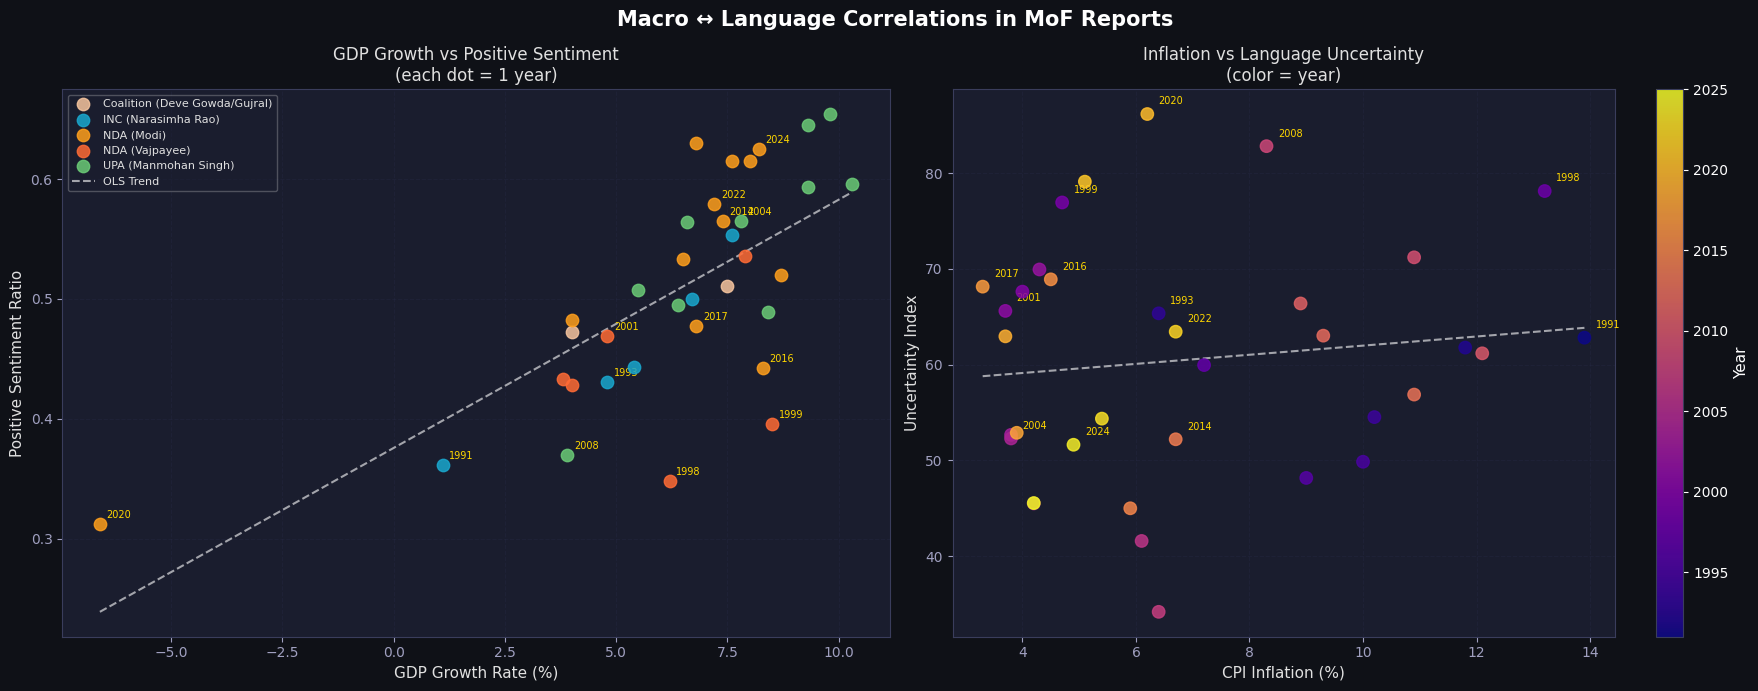

 Chart 10 saved.


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0F1117')


ax = axes[0]
ax.set_facecolor('#1A1D2E')
for party, grp in df.groupby('party'):
    color = PARTY_COLORS[party]
    ax.scatter(grp.gdp_growth, grp.positive_ratio,
               color=color, s=80, alpha=0.85, label=party, zorder=5)
    for _, row in grp.iterrows():
        if row.event:
            ax.annotate(str(row.year),
                       xy=(row.gdp_growth, row.positive_ratio),
                       xytext=(row.gdp_growth+0.15, row.positive_ratio+0.005),
                       fontsize=7, color='#FFD700')


from numpy.polynomial.polynomial import polyfit
c, m = polyfit(df.gdp_growth, df.positive_ratio, 1)
xfit = np.linspace(df.gdp_growth.min(), df.gdp_growth.max(), 100)
ax.plot(xfit, c + m*xfit, 'w--', linewidth=1.5, alpha=0.6, label='OLS Trend')

ax.set_xlabel('GDP Growth Rate (%)', fontsize=11)
ax.set_ylabel('Positive Sentiment Ratio', fontsize=11)
ax.set_title('GDP Growth vs Positive Sentiment\n(each dot = 1 year)', fontsize=12)
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True, alpha=0.3)


ax2 = axes[1]
ax2.set_facecolor('#1A1D2E')
sc = ax2.scatter(df.inflation, df.uncertainty_index,
                 c=df.year, cmap='plasma', s=80, alpha=0.85, zorder=5)
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('Year', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

for _, row in df[df.event != ''].iterrows():
    ax2.annotate(str(row.year),
                xy=(row.inflation, row.uncertainty_index),
                xytext=(row.inflation+0.2, row.uncertainty_index+1),
                fontsize=7, color='#FFD700')

c2, m2 = polyfit(df.inflation, df.uncertainty_index, 1)
xf2 = np.linspace(df.inflation.min(), df.inflation.max(), 100)
ax2.plot(xf2, c2 + m2*xf2, 'w--', linewidth=1.5, alpha=0.6)

ax2.set_xlabel('CPI Inflation (%)', fontsize=11)
ax2.set_ylabel('Uncertainty Index', fontsize=11)
ax2.set_title('Inflation vs Language Uncertainty\n(color = year)', fontsize=12)
ax2.grid(True, alpha=0.3)

fig.suptitle('Macro ↔ Language Correlations in MoF Reports',
             fontsize=15, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('chart10_scatter_macro_nlp.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 10 saved.")

##  Chart 11: Event-Specific Shock Analysis — Before vs After Comparison

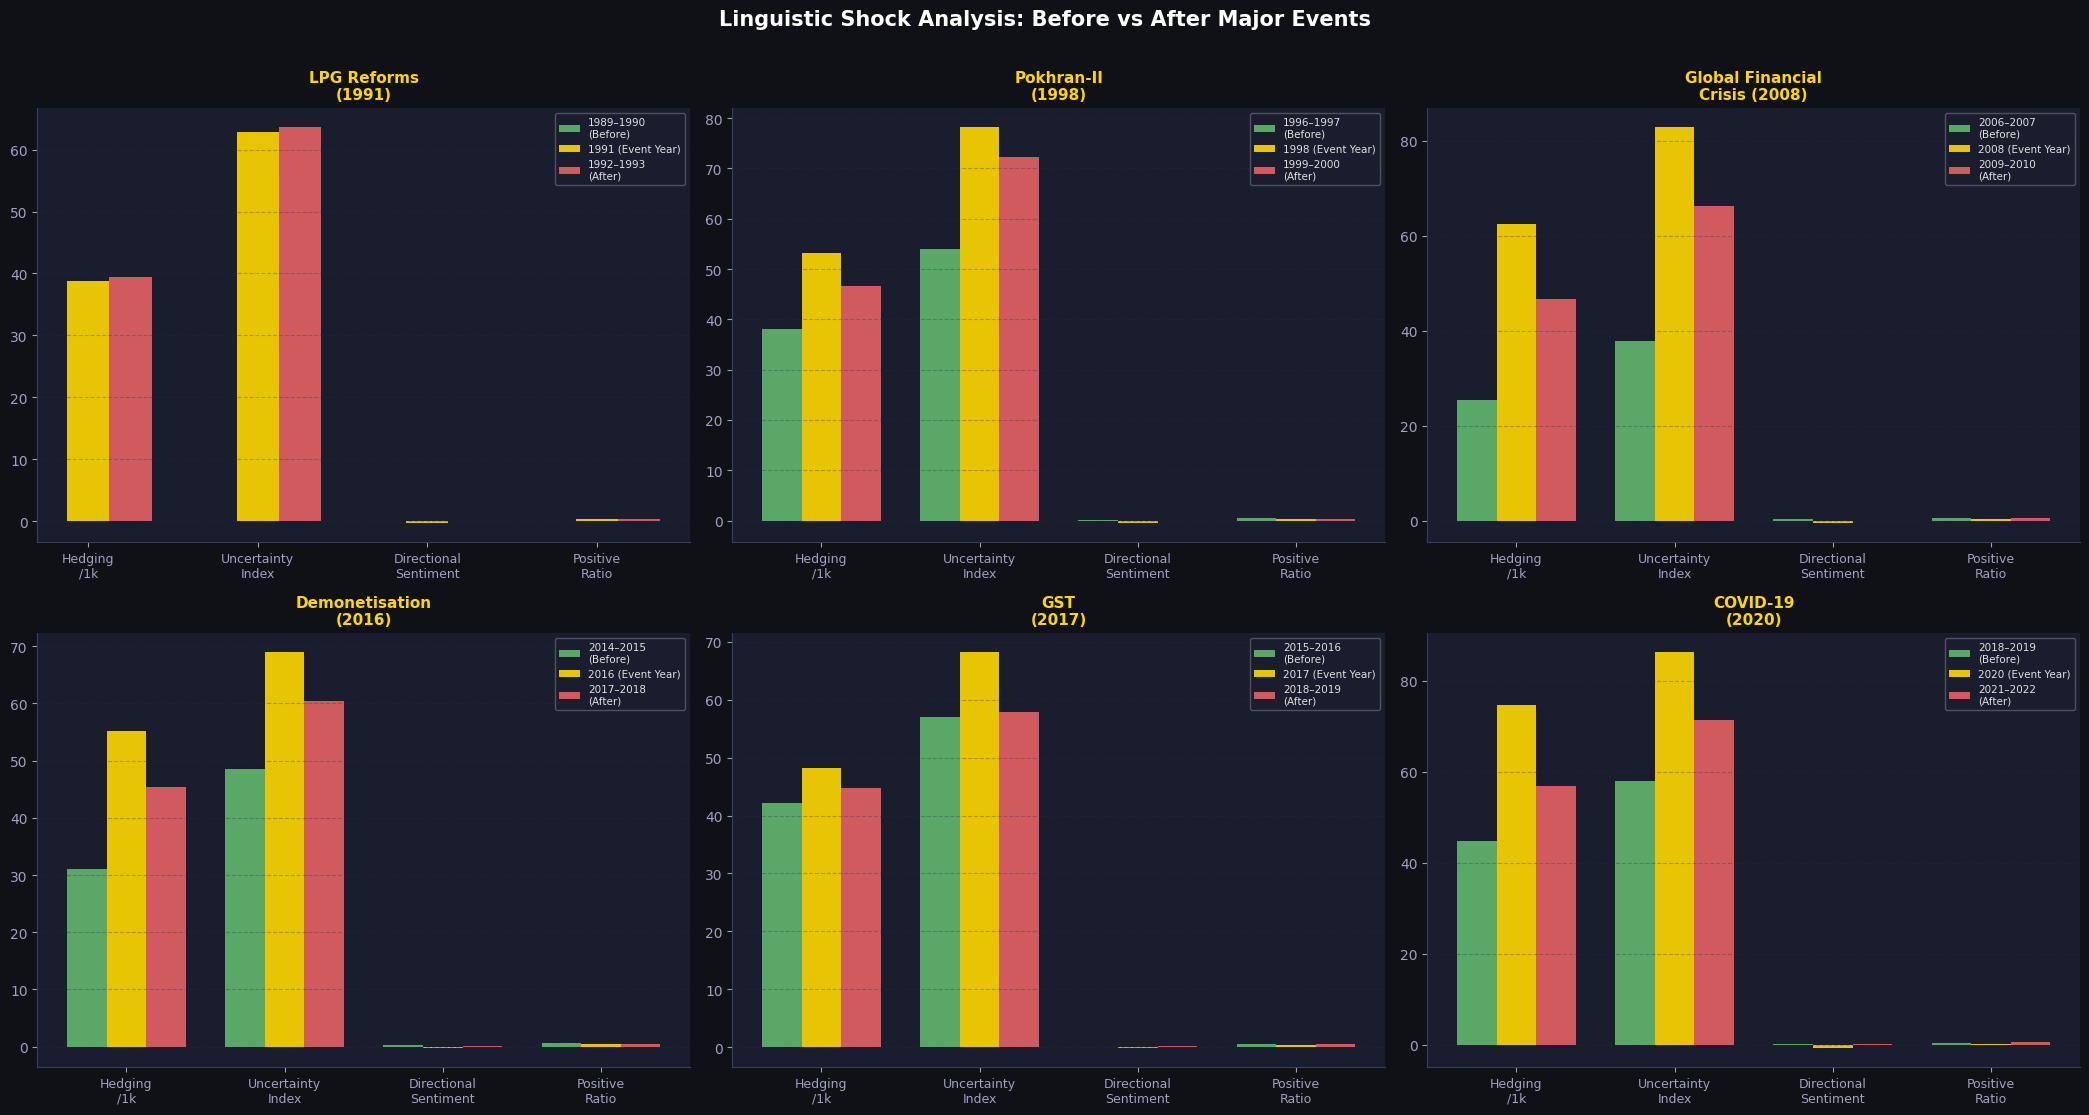

 Chart 11 saved.


In [63]:
shock_events = {
    'LPG Reforms\n(1991)':       1991,
    'Pokhran-II\n(1998)':        1998,
    'Global Financial\nCrisis (2008)': 2008,
    'Demonetisation\n(2016)':    2016,
    'GST\n(2017)':               2017,
    'COVID-19\n(2020)':          2020,
}

compare_cols = ['hedging_per_1k','uncertainty_index','directional_sent','positive_ratio']
compare_labels = ['Hedging\n/1k','Uncertainty\nIndex','Directional\nSentiment','Positive\nRatio']

window = 2

fig, axes = plt.subplots(2, 3, figsize=(21, 11), facecolor='#0F1117')
fig.suptitle('Linguistic Shock Analysis: Before vs After Major Events',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for ax, (ev_name, ev_yr) in zip(axes.flatten(), shock_events.items()):
    ax.set_facecolor('#1A1D2E')
    before = df[(df.year >= ev_yr-window) & (df.year < ev_yr)][compare_cols].mean()
    after  = df[(df.year > ev_yr) & (df.year <= ev_yr+window)][compare_cols].mean()
    at_yr  = df[df.year == ev_yr][compare_cols].mean()

    x = np.arange(len(compare_cols))
    w = 0.25
    ax.bar(x - w, before.values, w, label=f'{ev_yr-window}–{ev_yr-1}\n(Before)',
           color='#6BCB77', alpha=0.8)
    ax.bar(x,     at_yr.values,  w, label=f'{ev_yr} (Event Year)',
           color='#FFD700', alpha=0.9)
    ax.bar(x + w, after.values,  w, label=f'{ev_yr+1}–{ev_yr+window}\n(After)',
           color='#FF6B6B', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(compare_labels, fontsize=9)
    ax.set_title(ev_name, fontsize=11, color='#FFD700', fontweight='bold')
    ax.legend(fontsize=7.5, framealpha=0.3)
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart11_shock_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 11 saved.")

##  Chart 12: Rolling 3-Year Sentiment Trends (Multi-Line)

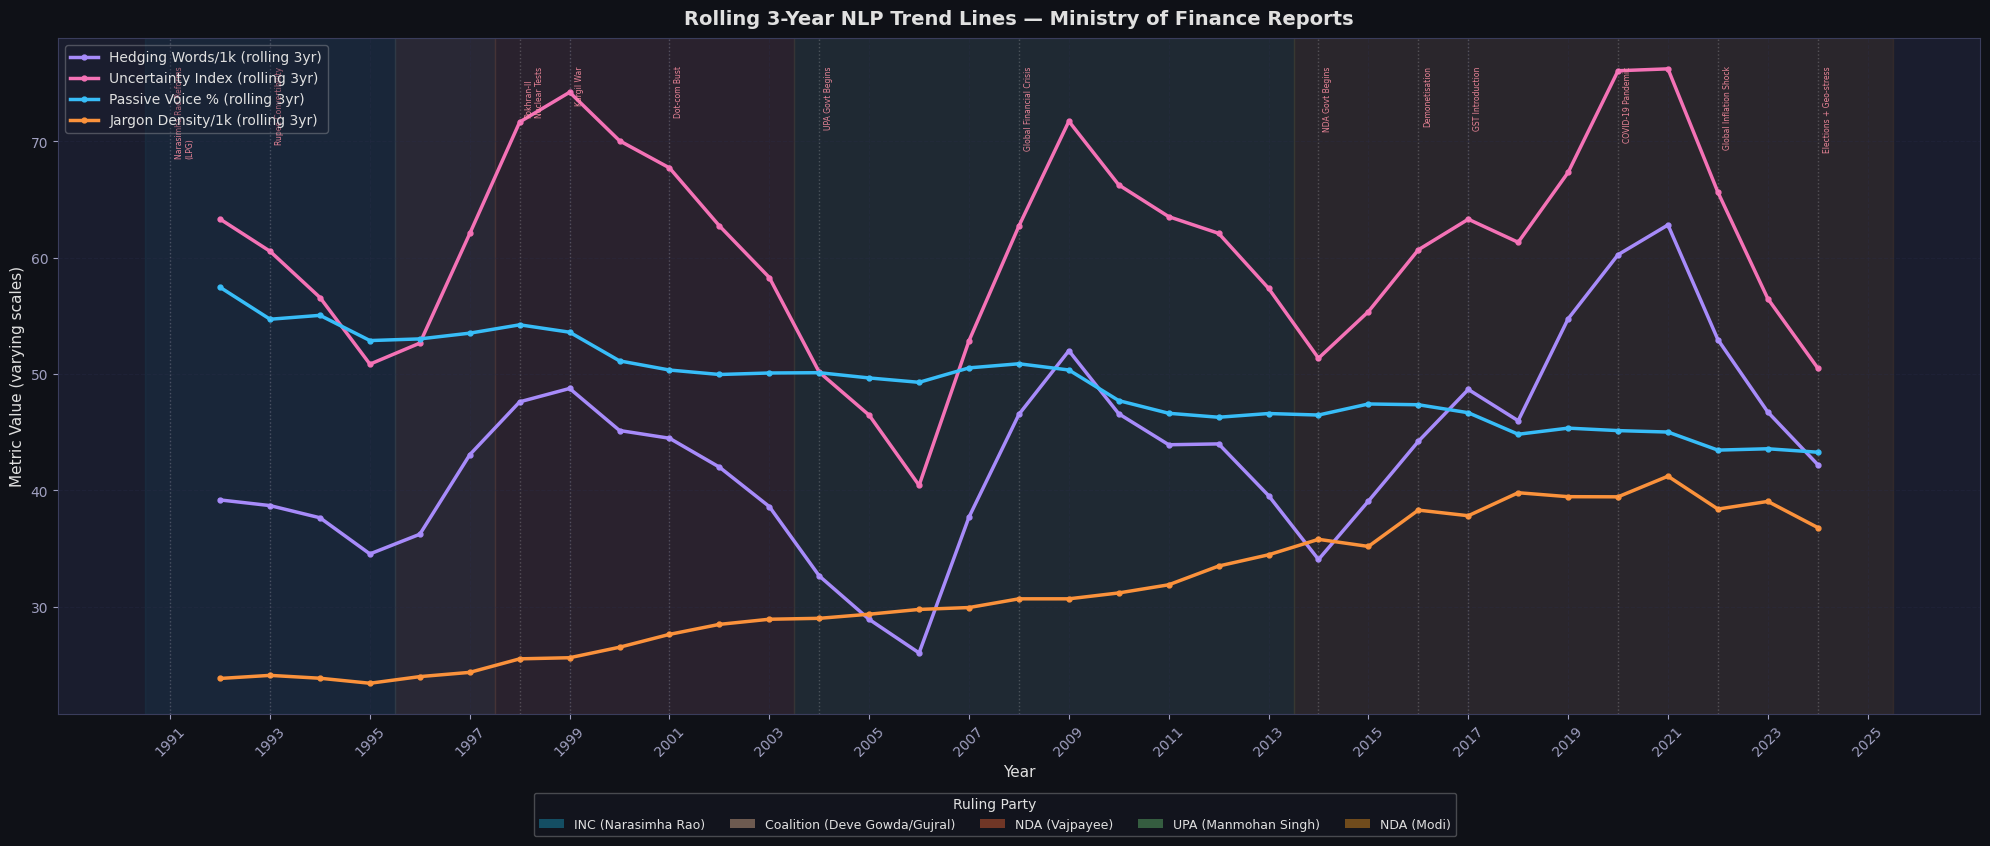

 Chart 12 saved.


In [64]:
fig, ax = plt.subplots(figsize=(20, 8), facecolor='#0F1117')
ax.set_facecolor('#1A1D2E')

add_party_bands(ax, df)

roll = df.set_index('year').rolling(3, center=True)

lines_config = [
    ('hedging_per_1k',    '#A78BFA', 'Hedging Words/1k (rolling 3yr)'),
    ('uncertainty_index', '#F472B6', 'Uncertainty Index (rolling 3yr)'),
    ('passive_voice_pct', '#38BDF8', 'Passive Voice % (rolling 3yr)'),
    ('jargon_density',    '#FB923C', 'Jargon Density/1k (rolling 3yr)'),
]

for col, color, label in lines_config:
    series = roll[col].mean().reset_index()
    ax.plot(series.year, series[col], color=color,
            linewidth=2.5, label=label, marker='o', markersize=3.5)


for yr, lbl in events.items():
    ax.axvline(yr, color='white', alpha=0.2, linewidth=1, linestyle=':')
    ax.text(yr+0.1, ax.get_ylim()[1]*0.97, lbl,
            rotation=90, fontsize=5.5, color='#FF8FA3', alpha=0.9,
            va='top', ha='left')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Metric Value (varying scales)', fontsize=11)
ax.set_title('Rolling 3-Year NLP Trend Lines — Ministry of Finance Reports',
             fontsize=14, fontweight='bold', pad=10)
ax.set_xticks(range(1991, 2026, 2))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', fontsize=10, framealpha=0.3)
ax.grid(True, alpha=0.3)

fig.legend(handles=party_legend(), loc='lower center', ncol=5,
           fontsize=9, framealpha=0.3, title='Ruling Party',
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig('chart12_rolling_trends.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(" Chart 12 saved.")

##  Chart 13: Summary Stats Table by Political Era

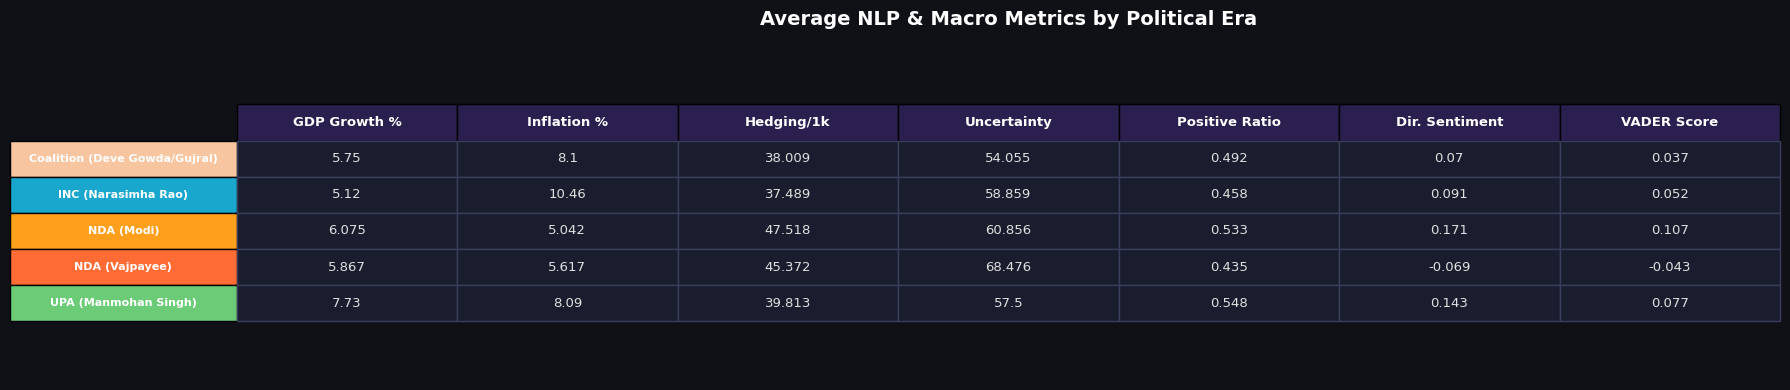


 Summary Table:
                               GDP Growth %  Inflation %  Hedging/1k  Uncertainty  Positive Ratio  Dir. Sentiment  VADER Score
Political Era                                                                                                                 
Coalition (Deve Gowda/Gujral)         5.750        8.100      38.009       54.055           0.492           0.070        0.037
INC (Narasimha Rao)                   5.120       10.460      37.489       58.859           0.458           0.091        0.052
NDA (Modi)                            6.075        5.042      47.518       60.856           0.533           0.171        0.107
NDA (Vajpayee)                        5.867        5.617      45.372       68.476           0.435          -0.069       -0.043
UPA (Manmohan Singh)                  7.730        8.090      39.813       57.500           0.548           0.143        0.077

 Chart 13 saved.


In [65]:
summary_cols = ['gdp_growth','inflation','hedging_per_1k','uncertainty_index',
                'positive_ratio','directional_sent','vader_compound']
summary_labels = ['GDP Growth %','Inflation %','Hedging/1k','Uncertainty',
                  'Positive Ratio','Dir. Sentiment','VADER Score']

era_summary = df.groupby('party')[summary_cols].mean().round(3)
era_summary.columns = summary_labels
era_summary.index.name = 'Political Era'

fig, ax = plt.subplots(figsize=(18, 4), facecolor='#0F1117')
ax.axis('off')

table = ax.table(
    cellText=era_summary.values,
    rowLabels=era_summary.index,
    colLabels=era_summary.columns,
    cellLoc='center', rowLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2)


for j in range(len(summary_labels)):
    table[0, j].set_facecolor('#2A1F4E')
    table[0, j].set_text_props(color='white', fontweight='bold')


row_colors = list(PARTY_COLORS.values())
for i, era in enumerate(era_summary.index, 1):
    color = PARTY_COLORS.get(era, '#444')
    table[i, -1].set_facecolor(color)
    table[i, -1].set_text_props(color='white', fontweight='bold', fontsize=8)
    for j in range(len(summary_labels)):
        table[i, j].set_facecolor('#1A1D2E')
        table[i, j].set_text_props(color='#E0E0E0')
        table[i, j].set_edgecolor('#3A3D5C')

ax.set_title('Average NLP & Macro Metrics by Political Era',
             fontsize=14, fontweight='bold', color='white', pad=15)

plt.tight_layout()
plt.savefig('chart13_summary_table.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()

print("\n Summary Table:")
print(era_summary.to_string())
print("\n Chart 13 saved.")

##  Section 4: Real NLP Engine (for Actual PDF Text)

In [66]:

import re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()
STOPWORDS = set(stopwords.words('english'))


HEDGING_WORDS = set([
    'may','might','could','perhaps','possibly','probably','likely','unlikely',
    'suggest','indicate','appear','seem','tend','roughly','approximately',
    'around','about','generally','often','sometimes','usually','largely',
    'broadly','potentially','arguably','conceivably','ostensibly'
])

UNCERTAINTY_PHRASES = [
    r'subject to',r'depending on',r'remains to be seen',r'uncertain',
    r'unpredictable',r'volatile',r'contingent',r'risk[s]?',r'challenge[s]?',
    r'if.*then',r'range of',r'estimated at',r'projected to',r'expected to'
]

POSITIVE_FIN = set(['growth','reform','improve','recovery','surplus','achieve',
                    'strengthen','robust','resilient','stable','progress',
                    'increase','expand','flourish','opportunity','success'])
NEGATIVE_FIN = set(['deficit','decline','crisis','inflation','recession','risk',
                    'downturn','slowdown','debt','concern','pressure','volatility',
                    'challenge','loss','fall','decrease','shock'])

def analyze_text(text):
    """Full NLP pipeline for one year's report."""
    text_lower = text.lower()
    tokens = word_tokenize(text_lower)
    tokens_clean = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
    sents  = sent_tokenize(text)
    n_tok  = max(len(tokens), 1)


    hedging = sum(1 for t in tokens_clean if t in HEDGING_WORDS)
    hedging_per_1k = hedging / n_tok * 1000


    unc_hits = sum(1 for pat in UNCERTAINTY_PHRASES
                   if re.search(pat, text_lower))
    uncertainty_index = min(100, unc_hits * 6)


    pos_count = sum(1 for t in tokens_clean if t in POSITIVE_FIN)
    neg_count = sum(1 for t in tokens_clean if t in NEGATIVE_FIN)
    total_pn  = max(pos_count + neg_count, 1)
    pos_ratio = pos_count / total_pn
    neg_ratio = neg_count / total_pn


    sample = ' '.join(sents[:50])
    vader_score = vader.polarity_scores(sample)['compound']


    passive = len(re.findall(r'\b(was|were|been|is|are)\s+\w+ed\b', text_lower))
    passive_pct = min(70, passive / max(len(sents), 1) * 100)


    future_pos = len(re.findall(r'will (?:grow|increase|improve|rise|strengthen)', text_lower))
    future_neg = len(re.findall(r'will (?:decline|fall|decrease|worsen|contract)', text_lower))
    dir_sent   = (future_pos - future_neg) / max(future_pos + future_neg, 1)


    avg_sent_len = np.mean([len(word_tokenize(s)) for s in sents]) if sents else 0

    return dict(
        hedging_per_1k=hedging_per_1k,
        uncertainty_index=uncertainty_index,
        positive_ratio=pos_ratio,
        negative_ratio=neg_ratio,
        pos_words_per_1k=pos_count/n_tok*1000,
        neg_words_per_1k=neg_count/n_tok*1000,
        vader_compound=vader_score,
        passive_voice_pct=passive_pct,
        directional_sent=dir_sent,
        avg_sent_len=avg_sent_len,
    )

if real_texts:
    real_results = []
    for yr, txt in sorted(real_texts.items()):
        metrics_row = analyze_text(txt)
        metrics_row['year'] = yr
        real_results.append(metrics_row)
        print(f"   {yr}: hedging={metrics_row['hedging_per_1k']:.1f}, "
              f"uncertainty={metrics_row['uncertainty_index']:.0f}, "
              f"vader={metrics_row['vader_compound']:.3f}")
    df_real = pd.DataFrame(real_results)
    print(f"\n Real NLP complete for {len(df_real)} reports. Use df_real instead of df for charts above.")
else:
    print("ℹ  No real PDFs loaded. analyzer ready — set USE_REAL_PDFS=True to use it.")

ℹ  No real PDFs loaded. analyzer ready — set USE_REAL_PDFS=True to use it.


##  Section 5: Export Results to CSV & Download All Charts

In [68]:
import zipfile, os

df.to_csv('mof_nlp_results_1991_2025.csv', index=False)
print("✓ CSV saved: mof_nlp_results_1991_2025.csv")

charts = [f for f in os.listdir('.') if f.endswith('.png')]
charts.append('mof_nlp_results_1991_2025.csv')

with zipfile.ZipFile('MoF_NLP_Analysis_All_Charts.zip', 'w') as zf:
    for c in charts:
        if os.path.exists(c):
            zf.write(c)
            print(f"  ✓ Added: {c}")

print(f"\n✓ Archive created: MoF_NLP_Analysis_All_Charts.zip")
print(f"✓ Ready for dashboard!")

✓ CSV saved: mof_nlp_results_1991_2025.csv
  ✓ Added: chart10_scatter_macro_nlp.png
  ✓ Added: chart11_shock_analysis.png
  ✓ Added: chart12_rolling_trends.png
  ✓ Added: chart13_summary_table.png
  ✓ Added: chart1_gdp_inflation.png
  ✓ Added: chart2_hedging_uncertainty.png
  ✓ Added: chart3_pos_neg_words.png
  ✓ Added: chart4_directional_sentiment.png
  ✓ Added: chart5_sentiment_stacked.png
  ✓ Added: chart6_nlp_dashboard.png
  ✓ Added: chart7_radar_era.png
  ✓ Added: chart8_heatmap.png
  ✓ Added: mof_nlp_results_1991_2025.csv

✓ Archive created: MoF_NLP_Analysis_All_Charts.zip
✓ Ready for dashboard!


---
##  Notebook Complete

| Chart | What it Shows |
|-------|---------------|
| 1 | GDP Growth & Inflation with event markers & party bands |
| 2 | Hedging Words vs Uncertainty Index (dual axis) |
| 3 | Positive vs Negative word counts (mirror area chart) |
| 4 | Directional Sentiment Ratio (bar + trend) |
| 5 | Sentiment composition 100% stacked area |
| 6 | 6-panel NLP metrics dashboard |
| 7 | Radar chart — NLP profile by political era |
| 8 | Heatmap — all metrics × all years |
| 9 | WordClouds by era |
| 10 | Scatter: GDP↔Sentiment, Inflation↔Uncertainty |
| 11 | Shock analysis: Before vs During vs After each event |
| 12 | Rolling 3-year NLP trend lines |
| 13 | Summary stats table by political era |

**To use real reports:** Set `USE_REAL_PDFS = True` and upload `1991.pdf`, `1992.pdf` ... in Section 1.

In [ ]:
pip install streamlit plotly pandas

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached starlette-1.0.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached httptools-0.7.1-cp310-cp310-win_amd64.whl.metadata (3.6 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached websockets-16.0-cp310-cp310-win_amd64.whl.metadata (7.0 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached h11-0.16.0-py3-none-any.

In [ ]:
streamlit run ./dashboard.py

SyntaxError: invalid syntax (512221001.py, line 1)